In [3]:
from pathlib import Path

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [5]:
filtered_texts = pd.read_csv("../data/filtered_fashion_texts.csv")

In [6]:
print(filtered_texts.columns)

Index(['filename', 'sentence', 'term', 'start_idx', 'end_idx',
       'sentence_start_idx', 'sentence_end_idx', 'label', 'confidence'],
      dtype='object')


In [7]:
def open_novel_metadata(chicago_corpus_path: Path | str):
    if isinstance(chicago_corpus_path, str):
        chicago_corpus_path = Path(chicago_corpus_path)
    return pd.concat([
        pd.read_csv(chicago_corpus_path / "CHICAGO_CORPUS/CHICAGO_NOVEL_CORPUS_METADATA/CHICAGO_CORPUS_NOVELS.csv"),
        pd.read_csv(chicago_corpus_path / "CHICAGO_CORPUS/CHICAGO_NOVEL_CORPUS_METADATA/CHICAGO_CORPUS_NOVELS2.csv")
    ]).drop_duplicates(subset=["FILENAME"])

In [8]:
author_meta = pd.read_csv("../data/ChicagoCorpus/CHICAGO_CORPUS/CHICAGO_NOVEL_CORPUS_METADATA/CHICAGO_CORPUS_AUTHORS.csv")

In [9]:
novels_meta = open_novel_metadata("../data/ChicagoCorpus/")

In [10]:
sentence_counts = pd.read_csv("../data/sentence_counts.csv")

In [11]:
novels_meta = novels_meta.merge(sentence_counts, left_on="FILENAME", right_on="filename").drop("filename", axis=1)

In [12]:
joined = filtered_texts.merge(novels_meta, left_on="filename", right_on="FILENAME", how="left")
joined = joined.merge(author_meta, left_on="AUTH_ID", right_on="AUTH_ID", how="left")

In [8]:
paragraphs = pd.read_csv("../data/extracted_paragraphs.csv")

# Fashion terms mentioned

In [33]:
joined.term.value_counts()

term
clothes       56579
shirt         43503
coat          38774
dress         36437
hat           34470
              ...  
izar              1
aventail          1
lambrequin        1
separate          1
haik              1
Name: count, Length: 480, dtype: int64

# Average number of fashion mentions per book by year

In [77]:
year_book_counts = joined.set_index("PUBL_DATE").groupby("PUBL_DATE").BOOK_ID.value_counts().reset_index()

In [102]:
year_book_props = (year_book_counts.set_index(["PUBL_DATE", "BOOK_ID"])["count"] / joined.groupby(["PUBL_DATE", "BOOK_ID"])["sentence_count"].agg("first")).rename("count").reset_index()

In [103]:
year_book_counts

,PUBL_DATE,BOOK_ID,count
0,1920.0,4485.0,66
1,1921.0,4593.0,104
2,1921.0,4599.0,32
3,1921.0,4529.0,23
4,1922.0,4705.0,77
...,...,...,...
3926,1990.0,23272.0,32
3927,1990.0,23386.0,32
3928,1990.0,23322.0,30
3929,1990.0,23400.0,30


In [104]:
year_book_props

,PUBL_DATE,BOOK_ID,count
0,1920.0,4485.0,0.010726
1,1921.0,4529.0,0.016999
2,1921.0,4593.0,0.018615
3,1921.0,4599.0,0.016385
4,1922.0,4655.0,0.012051
...,...,...,...
3926,1990.0,23460.0,0.017376
3927,1990.0,23461.0,0.023786
3928,1990.0,23462.0,0.010988
3929,1990.0,23463.0,0.011916


In [78]:
from pyloess import loess
from tqdm.auto import tqdm

def lowess_with_confidence_bounds(
    x, y, eval_x, N=200, conf_interval=0.95, lowess_kw=None, progress=True, groups=None
):
    """
    Perform Lowess regression and determine a confidence interval by bootstrap resampling
    """
    # Lowess smoothing
    smoothed = loess(x, y, eval_x=eval_x, **lowess_kw)

    if groups is None:
        groups = np.arange(0, len(x))
    unique_groups = np.unique(groups)

    # Perform bootstrap resamplings of the data
    # and  evaluate the smoothing at a fixed set of points
    smoothed_values = np.empty((N, len(eval_x)))
    for i in tqdm(range(N), disable=(not progress)):
        # sample = np.random.choice(len(x), len(x), replace=True)
        sample_groups = np.random.choice(unique_groups, len(unique_groups), replace=True)
        sample = np.isin(groups, sample_groups)
        sampled_x = x[sample]
        sampled_y = y[sample]

        smoothed_values[i] = loess(
            sampled_x, sampled_y, eval_x=eval_x, **lowess_kw
        )

    # Get the confidence interval
    sorted_values = np.sort(smoothed_values, axis=0)
    bound = int(N * (1 - conf_interval) / 2)
    bottom = sorted_values[bound - 1]
    top = sorted_values[-bound]

    return smoothed, bottom, top


  0%|          | 0/50 [00:00<?, ?it/s]

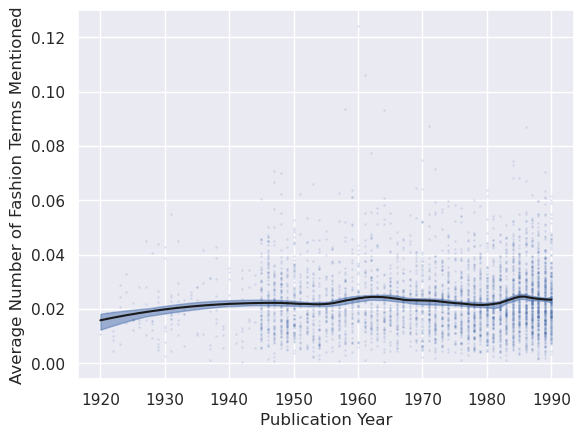

In [105]:

def _(df):
    x = df.PUBL_DATE.to_numpy()
    y = df["count"].to_numpy()
    x_new = np.linspace(x.min(), x.max(), 1000)
   
    smoothed, bottom, top = lowess_with_confidence_bounds(x, y, x_new, lowess_kw=dict(span=0.33, degree=2), N=50)
    
    fig, ax = plt.subplots()
    ax.scatter(x, y, s=1, alpha=0.1)
    ax.plot(x_new, smoothed, c="k")
    ax.fill_between(x_new, bottom, top, alpha=0.5, color="b")
    plt.xlabel("Publication Year")
    plt.ylabel("Average Number of Fashion Terms Mentioned")
    plt.show()

_(year_book_props)

<Axes: xlabel='PUBL_DATE', ylabel='count'>

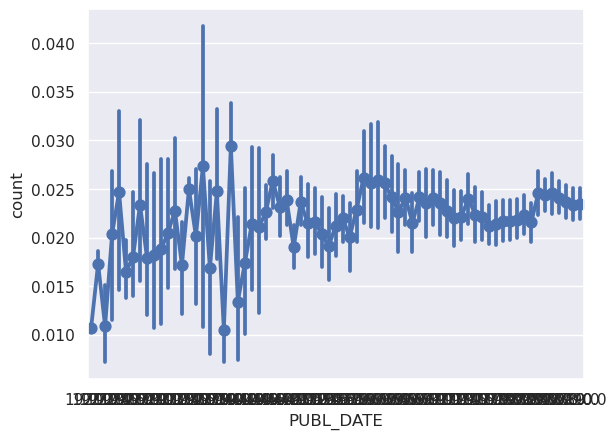

In [107]:
sns.pointplot(data=year_book_props, x="PUBL_DATE", y="count")

# Fashion mentions by gender

We can look at the proportion of fashion mentions by M vs W authors over time.

In [109]:
# average number of fashion mentions per book by M vs W authors
gender_book_counts = joined.set_index("PUBL_DATE").groupby(["PUBL_DATE", "GENDER"]).BOOK_ID.value_counts().reset_index()
gender_book_props = (gender_book_counts.set_index(["PUBL_DATE", "GENDER", "BOOK_ID"])["count"] / joined.groupby(["PUBL_DATE", "GENDER", "BOOK_ID"])["sentence_count"].agg("first")).rename("count").reset_index()


<Axes: xlabel='PUBL_DATE', ylabel='count'>

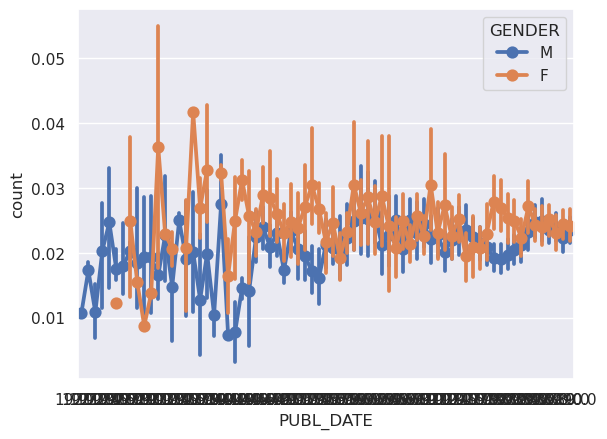

In [112]:
sns.pointplot(data=gender_book_props, x="PUBL_DATE", y="count", hue="GENDER")

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

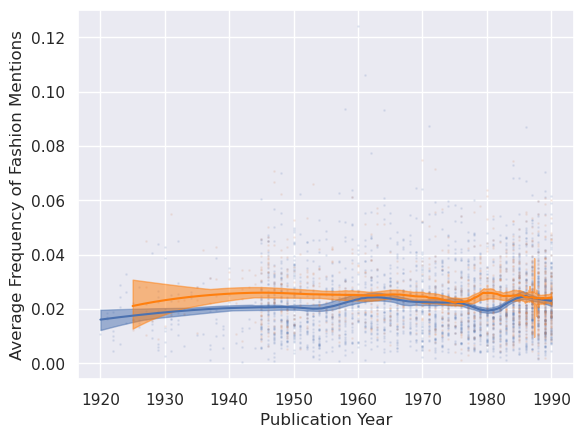

In [117]:
def _(df):
    # year_book_counts = joined.set_index("PUBL_DATE").groupby(["PUBL_DATE", "GENDER"]).BOOK_ID.value_counts().reset_index()
    
    fig, ax = plt.subplots()

    color_map = {"M": "b", "F": "tab:orange"}

    for g in ["M", "F"]:
        data = df[df.GENDER.eq(g)]
        x = data.PUBL_DATE.to_numpy()
        y = data["count"].to_numpy()
        x_new = np.linspace(x.min(), x.max(), 1000)
       
        smoothed, bottom, top = lowess_with_confidence_bounds(x, y, x_new, lowess_kw=dict(span=0.33, degree=2), N=50)
        
        ax.scatter(x, y, s=1, alpha=0.1)
        ax.plot(x_new, smoothed, c=color_map[g])
        ax.fill_between(x_new, bottom, top, alpha=0.5, color=color_map[g])

    plt.xlabel("Publication Year")
    plt.ylabel("Average Frequency of Fashion Mentions")
    plt.show()
_(gender_book_props)

<Axes: xlabel='GENDER', ylabel='count'>

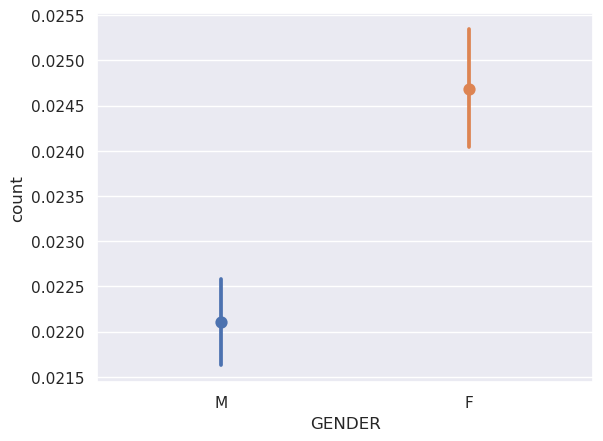

In [115]:
sns.pointplot(data=gender_book_props, x="GENDER", y="count", hue="GENDER")

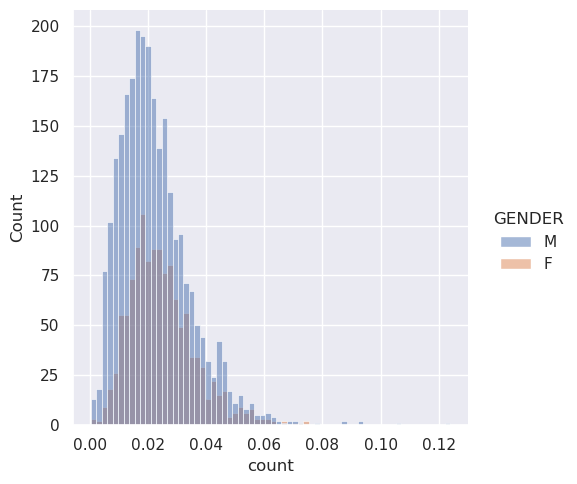

In [116]:
sns.displot(data=gender_book_props, x="count", hue="GENDER")

In [19]:
joined.PUBL_DATE

0         1972.0
1         1972.0
2         1972.0
3         1972.0
4         1972.0
           ...  
624444    1976.0
624445    1976.0
624446    1976.0
624447    1976.0
624448    1976.0
Name: PUBL_DATE, Length: 624449, dtype: float64

# Fashion mentions by position

In [34]:
lengths = paragraphs.groupby("filename").end_idx.max()

In [44]:
joined = joined.merge(lengths.rename("char_length"), on="filename", how="left")

In [45]:
joined.head()

,filename,sentence,term,start_idx,end_idx,sentence_start_idx,sentence_end_idx,label,confidence,BOOK_ID,...,IMMIGRANT,SEXUAL_IDENTITY,EDUCATION,MFA,SECONDARY_OCCUPATION,COTERIE,RELIGION,CLASS,GEOGRAPHY,char_length
0,00021035.txt,"\nOne\n\n\n\n\nTHE WELCOME WAGON lady, sixty i...",dress,132,137,0,225,0,0.519228,21035.0,...,NaN,NaN,NYU,NaN,NaN,NaN,NaN,NaN,"New York, NY",186168
1,00021035.txt,"It was Walter’s turn to do the dishes, and Pet...",shorts,136,142,5813,6006,0,0.519264,21035.0,...,NaN,NaN,NYU,NaN,NaN,NaN,NaN,NaN,"New York, NY",186168
2,00021035.txt,"It was Walter’s turn to do the dishes, and Pet...",shirt,149,154,5813,6006,0,0.519236,21035.0,...,NaN,NaN,NYU,NaN,NaN,NaN,NaN,NaN,"New York, NY",186168
3,00021035.txt,A Rorschach-blot of sweat stained his shirt: a...,shirt,38,43,6602,6683,0,0.519233,21035.0,...,NaN,NaN,NYU,NaN,NaN,NaN,NaN,NaN,"New York, NY",186168
4,00021035.txt,"Carol straightened and stood facing her, tall ...",dress,123,128,10959,11088,0,0.519208,21035.0,...,NaN,NaN,NYU,NaN,NaN,NaN,NaN,NaN,"New York, NY",186168


In [46]:
joined.sentence_start_idx

0              0
1           5813
2           5813
3           6602
4          10959
           ...  
624407    402280
624408    402876
624409    403158
624410    412327
624411    423858
Name: sentence_start_idx, Length: 624412, dtype: int64

In [37]:
filtered_texts.head()

,filename,sentence,term,start_idx,end_idx,sentence_start_idx,sentence_end_idx,label,confidence
0,00021035.txt,"\nOne\n\n\n\n\nTHE WELCOME WAGON lady, sixty i...",dress,132,137,0,225,0,0.519228
1,00021035.txt,"It was Walter’s turn to do the dishes, and Pet...",shorts,136,142,5813,6006,0,0.519264
2,00021035.txt,"It was Walter’s turn to do the dishes, and Pet...",shirt,149,154,5813,6006,0,0.519236
3,00021035.txt,A Rorschach-blot of sweat stained his shirt: a...,shirt,38,43,6602,6683,0,0.519233
4,00021035.txt,"Carol straightened and stood facing her, tall ...",dress,123,128,10959,11088,0,0.519208


In [38]:
f = open("../data/ChicagoCorpus/CLEAN_TEXTS/00021035.txt").read()

In [39]:
f[692:892]

'The Welcome Wagon lady put a vial of cologne on top of the other things, and then searched in her bag—“No, really,” Joanna said—and brought out pink-framed eyeglasses and a small embroidered notebook.'

In [40]:
lengths

filename
00004449.txt     359257
00004458.txt     403700
00004459.txt     635576
00004463.txt     386515
00004485.txt     395264
                 ...   
00023609.txt    2235806
00023610.txt     244572
00023611.txt     331071
23375.txt        498805
23377.txt        633115
Name: end_idx, Length: 3974, dtype: int64

In [48]:
(joined.sentence_start_idx + joined.start_idx) / joined.char_length

0         0.000709
1         0.031955
2         0.032025
3         0.035667
4         0.059527
            ...   
624407    0.935725
624408    0.937230
624409    0.937870
624410    0.959195
624411    0.985965
Length: 624412, dtype: float64

In [59]:
((joined.sentence_start_idx + joined.start_idx) / joined.char_length).describe()

count    624412.000000
mean          0.479810
std           0.288880
min           0.000045
25%           0.228064
50%           0.470687
75%           0.727091
max           0.999991
dtype: float64

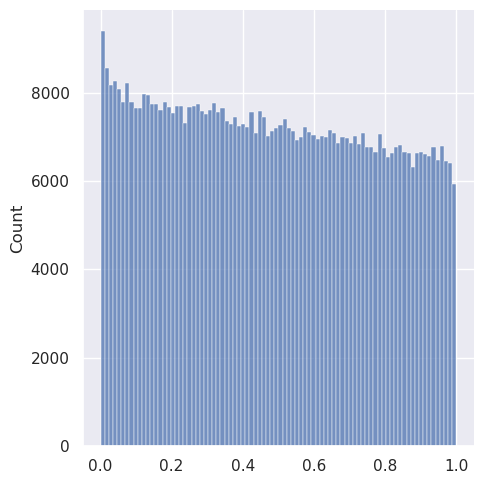

In [58]:
sns.displot(((joined.sentence_start_idx + joined.start_idx) / joined.char_length))

In [63]:
len(paragraphs.filename.unique())

3974

# Topic Modeling

In [118]:
import little_mallet_wrapper as lmw
path_to_mallet = '/mnt/data0/naitian/Mallet-202108/bin/mallet'

In [119]:
joined.head()

,filename,sentence,term,start_idx,end_idx,sentence_start_idx,sentence_end_idx,label,confidence,BOOK_ID,...,HYPHENATED_IDENTITY,IMMIGRANT,SEXUAL_IDENTITY,EDUCATION,MFA,SECONDARY_OCCUPATION,COTERIE,RELIGION,CLASS,GEOGRAPHY
0,00021035.txt,"\nOne\n\n\n\n\nTHE WELCOME WAGON lady, sixty i...",dress,132,137,0,225,0,0.519228,21035.0,...,NaN,NaN,NaN,NYU,NaN,NaN,NaN,NaN,NaN,"New York, NY"
1,00021035.txt,"It was Walter’s turn to do the dishes, and Pet...",shorts,136,142,5813,6006,0,0.519264,21035.0,...,NaN,NaN,NaN,NYU,NaN,NaN,NaN,NaN,NaN,"New York, NY"
2,00021035.txt,"It was Walter’s turn to do the dishes, and Pet...",shirt,149,154,5813,6006,0,0.519236,21035.0,...,NaN,NaN,NaN,NYU,NaN,NaN,NaN,NaN,NaN,"New York, NY"
3,00021035.txt,A Rorschach-blot of sweat stained his shirt: a...,shirt,38,43,6602,6683,0,0.519233,21035.0,...,NaN,NaN,NaN,NYU,NaN,NaN,NaN,NaN,NaN,"New York, NY"
4,00021035.txt,"Carol straightened and stood facing her, tall ...",dress,123,128,10959,11088,0,0.519208,21035.0,...,NaN,NaN,NaN,NYU,NaN,NaN,NaN,NaN,NaN,"New York, NY"


In [138]:
paragraphs.head(10)

,paragraph,start_idx,end_idx,paragraph_id,filename
0,"\nHAVING handed me my cup of tea, she pro \nce...",0,158,0,00004449.txt
1,The story is not my own she then began but \nt...,160,894,1,00004449.txt
2,7,896,898,2,00004449.txt
3,8 Master Eustace,902,919,5,00004449.txt
4,erally useful. Something in her tone and manne...,921,2329,6,00004449.txt
5,Master Eustace,2333,2348,9,00004449.txt
6,in making her had left out that wholesome lead...,2352,3773,12,00004449.txt
7,10 Master Eustace,3777,3795,15,00004449.txt
8,pie. To certain little luxuries she was obstin...,3797,5242,16,00004449.txt
9,Master Eustace 11_,5246,5265,19,00004449.txt


In [152]:
paragraphs.head(10).reset_index().groupby("filename").groups

{'00004449.txt': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}

In [172]:
@lambda x:x()
def clothing_paragraphs():
    clothing_paragraphs = []
    sentences = joined.groupby(["filename", "sentence"]).agg({
        "sentence_start_idx": "first", "sentence_end_idx": "first"
    }).reset_index()
    paragraph_inds = paragraphs.reset_index().groupby("filename").groups
    # for each sentence, find the paragraph that it's in
    for row in tqdm(sentences.itertuples(), total=len(sentences)):
        pars = paragraphs.loc[paragraph_inds[row.filename]]
        start_ind = np.searchsorted(pars.start_idx, row.sentence_start_idx, side="right") - 1
        end_ind = np.searchsorted(pars.end_idx, row.sentence_start_idx, side="left") 
        if start_ind != end_ind:
        #     print(start_ind, end_ind)
        #     print(row.filename)
        #     print(pars.iloc[start_ind].start_idx, row.sentence_start_idx, pars.iloc[end_ind].start_idx)
        #     print(pars.iloc[start_ind].end_idx, row.sentence_end_idx, pars.iloc[end_ind].end_idx)
            continue
        clothing_paragraphs.append(paragraph_inds[row.filename][start_ind])
        # clothing_paragraphs.extend(par)
    # df = joined.set_index("filename")
    # for row in tqdm(paragraphs.itertuples(), total=len(paragraphs)):
    #     # check if any of the joined sentences are included in this paragraph
    #     # included means sentence.start_idx >= paragraph.start_idx and sentence.end_idx <= paragraph.end_idx
    #     sents = df.loc[row.filename]
    #     clothing_paragraphs.append(any(sents.sentence_start_idx.ge(row.start_idx) & sents.sentence_end_idx.le(row.end_idx)))
    return paragraphs.loc[[int(i) for i in clothing_paragraphs]]

  0%|          | 0/506234 [00:00<?, ?it/s]

In [ ]:
@lambda x:x()
def clothing_contexts():
    clothing_paragraphs = []
    sentences = joined.groupby(["filename", "sentence"]).agg({
        "sentence_start_idx": "first", "sentence_end_idx": "first"
    }).reset_index()
    paragraph_inds = paragraphs.reset_index().groupby("filename").groups
    # for each sentence, find the paragraph that it's in
    for row in tqdm(sentences.itertuples(), total=len(sentences)):
        pars = paragraphs.loc[paragraph_inds[row.filename]]
        start_ind = np.searchsorted(pars.start_idx, row.sentence_start_idx, side="right") - 1
        end_ind = np.searchsorted(pars.end_idx, row.sentence_start_idx, side="left") 
        # if start_ind != end_ind:
        #     print(start_ind, end_ind)
        #     print(row.filename)
        #     print(pars.iloc[start_ind].start_idx, row.sentence_start_idx, pars.iloc[end_ind].start_idx)
        #     print(pars.iloc[start_ind].end_idx, row.sentence_end_idx, pars.iloc[end_ind].end_idx)
        #     continue
        clothing_paragraphs.append(paragraph_inds[row.filename][start_ind])
        # clothing_paragraphs.extend(par)
    # df = joined.set_index("filename")
    # for row in tqdm(paragraphs.itertuples(), total=len(paragraphs)):
    #     # check if any of the joined sentences are included in this paragraph
    #     # included means sentence.start_idx >= paragraph.start_idx and sentence.end_idx <= paragraph.end_idx
    #     sents = df.loc[row.filename]
    #     clothing_paragraphs.append(any(sents.sentence_start_idx.ge(row.start_idx) & sents.sentence_end_idx.le(row.end_idx)))
    return paragraphs.loc[[int(i) for i in clothing_paragraphs]]

In [179]:
clothing_paragraphs = paragraphs.loc[[int(i) for i in clothing_paragraphs]]

In [201]:
clothing_paragraphs.index[1]

np.int64(170)

In [209]:
clothing_paragraphs.loc[[int(clothing_paragraphs.index[i]) for i in training_inds]]

,paragraph,start_idx,end_idx,paragraph_id,filename
32,"cream, and a bottle of champagne was sent to t...",18236,19495,60,00004449.txt
170,sonal interest ; they watched them from day to...,73867,75277,284,00004449.txt
202,"Agatha bowed in silence, and, to make room for...",85200,85374,332,00004449.txt
946,"As there was no name on the parcel, Benvolio, ...",294643,295623,1440,00004449.txt
900,when he wished to learn with the least trouble...,268936,270376,1352,00004449.txt
...,...,...,...,...,...
10347794,"“Welcome,” my mother said, and pushed past us ...",434160,434839,1111,23377.txt
10347794,"“Welcome,” my mother said, and pushed past us ...",434160,434839,1111,23377.txt
10346813,“Wouldn’t you love to have peacocks in your ya...,17286,18506,30,23377.txt
10348124,"“I’m sorry I was so short with you yesterday,”...",554014,554444,1461,23377.txt


In [211]:
training_par_inds = [int(clothing_paragraphs.index[i]) for i in training_inds]

In [214]:
training_clothing_pars = clothing_paragraphs.loc[training_par_inds]

In [190]:
training_data = [lmw.process_string(t) for t in tqdm(clothing_paragraphs.paragraph.tolist())]
training_data, training_inds = zip(*((d, i) for i, d in enumerate(training_data) if d.strip()))

  0%|          | 0/506234 [00:00<?, ?it/s]

In [182]:
num_topics = 50
output_directory_path = f"../data/topics_{num_topics}"
Path(output_directory_path).mkdir(exist_ok=True, parents=True)
topic_keys, topic_distributions = lmw.quick_train_topic_model(path_to_mallet, 
                                                              output_directory_path, 
                                                              num_topics, 
                                                              training_data)

Importing data...
Complete
Training topic model...


Mallet LDA: 50 topics, 6 topic bits, 111111 topic mask
Data loaded.
max tokens: 46442
total tokens: 29010888
<10> LL/token: -10.78576
<20> LL/token: -10.11857
<30> LL/token: -9.85618
<40> LL/token: -9.72101

0	0.1	man hand face eyes back head mask turned one belt stood saw moment cloak looked away said hands toward sword 
1	0.1	would could like said didn know never think clothes even thought way say get one want see wanted really time 
2	0.1	white shoes blue shirt suit one clothes pair black wearing new jacket dress tie sweater wore shirts socks two pants 
3	0.1	eyes light saw could see face looked stood turned dark door back seemed toward behind moment still looking came away 
4	0.1	back like got one get around big right little guy car time going old see way pants says come didn 
5	0.1	bed clothes felt cold water back still room sleep put lay night warm robe body wet went shirt door could 
6	0.1	cloak horse helmet could back head one away sword belt man time saw behind still would aro

Complete


In [218]:
training_par_inds[:10]

[32, 170, 202, 946, 900, 874, 709, 320, 30, 752]

In [ ]:
clothing_paragraphs

In [217]:
clothing_paragraphs.loc[training_par_inds[:10]]

,paragraph,start_idx,end_idx,paragraph_id,filename
32,"cream, and a bottle of champagne was sent to t...",18236,19495,60,00004449.txt
170,sonal interest ; they watched them from day to...,73867,75277,284,00004449.txt
202,"Agatha bowed in silence, and, to make room for...",85200,85374,332,00004449.txt
946,"As there was no name on the parcel, Benvolio, ...",294643,295623,1440,00004449.txt
900,when he wished to learn with the least trouble...,268936,270376,1352,00004449.txt
900,when he wished to learn with the least trouble...,268936,270376,1352,00004449.txt
874,of a well-favored young man; but I am bound to...,253636,255084,1302,00004449.txt
709,"to find lodging for. At the age of twenty, poo...",210184,211618,1067,00004449.txt
320,"Longstaff heard it; he gave a long,- soft moan...",110660,111201,488,00004449.txt
320,"Longstaff heard it; he gave a long,- soft moan...",110660,111201,488,00004449.txt


In [184]:
topic_distributions = np.array(topic_distributions)

In [189]:
len(clothing_paragraphs)

506234

In [188]:
len(training_data)

505121

In [187]:
topic_distributions.argmax(axis=1)

array([23, 17,  0, ...,  7, 22, 19], shape=(505121,))

In [232]:
print(training_clothing_pars.paragraph.sample(10).iloc[0])

The inhabitants, rotten with adventism, had rebelled. They had joined King Argon as his army had come through, and many of them had abandoned everything to follow it as it receded. Others had stripped off their clothes and run naked into the hills. In an adventist delirium, expecting their savior every minute, they had burned their crops. The monks had allowed only one food in each village, turnips for one, cabbages for another, and the tattoos of the villagers had prohibited them from touching anything but that one vegetable, boiled whole. For many that had been the bitterest part of slavery, and when King Argon came, they had torched their own fields, thinking that the land would blossom under the conqueror's feet, and sprout up fruits and flowers, and need no tending. Argon had encouraged the fantasy, but even so he had had them whipped, for he was desperate for the food. They had run off terrified into the hills.


# Clothing adjectives

In [13]:
import glob
def load_adjectives():
    all_dfs = []
    files = glob.glob("../data/adjectives/litbank_adjectives.*.csv")
    for file in files:
        df = pd.read_csv(file)
        all_dfs.append(df)
    return pd.concat(all_dfs)

adj_df = load_adjectives()

In [22]:
adj_df.loc[:, "mention"] = adj_df.apply(lambda x: x.sentence[x.mention_start_idx:x.mention_end_idx], axis=1)

In [31]:
adj_df.loc[:, "mention_counts"] = adj_df.groupby(adj_df.mention.str.lower()).sentence.transform(lambda x: len(x))

In [36]:
adj_df

,adjective,adjective_start_idx,adjective_end_idx,noun,noun_start_idx,noun_end_idx,negated,sentence,sentence_start_idx,sentence_end_idx,mention_start_idx,mention_end_idx,filename,mention,mention_counts
0,absolute,48,56,change,4,10,False,The change from day to night is as quick and a...,180122,180212,4,10,2166_king_solomons_mines.txt,change,473
1,quick,35,40,change,4,10,False,The change from day to night is as quick and a...,180122,180212,4,10,2166_king_solomons_mines.txt,change,473
2,royal,98,103,diadem,104,110,False,"""\n\nAfterwards, in the course of the morning,...",332219,332344,104,110,2166_king_solomons_mines.txt,diadem,3
3,prickly,75,82,flannel,87,94,False,The\nfirst (and the worst!) thing that confron...,26548,26664,87,94,44_the_song_of_the_lark.txt,flannel,71
4,fresh,96,101,flannel,87,94,False,The\nfirst (and the worst!) thing that confron...,26548,26664,87,94,44_the_song_of_the_lark.txt,flannel,71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,stiff,55,60,dress,67,72,False,But when her\neyes fell on the odd little figu...,42224,42394,67,72,45_anne_of_green_gables.txt,dress,605
550,ugly,62,66,dress,67,72,False,But when her\neyes fell on the odd little figu...,42224,42394,67,72,45_anne_of_green_gables.txt,dress,605
551,new,37,40,coat,41,45,False,But in case I do go I’m very glad my\nnew coat...,415347,415420,41,45,45_anne_of_green_gables.txt,coat,547
552,ready,54,59,coat,41,45,False,But in case I do go I’m very glad my\nnew coat...,415347,415420,41,45,45_anne_of_green_gables.txt,coat,547


In [60]:
adj_df.groupby([adj_df.mention.str.lower(), adj_df.adjective.str.lower()]).agg({
    "sentence": "count",
    "mention_counts": "first"
}).reset_index().sort_values(by=["mention_counts", "mention", "sentence"], ascending=False).to_csv("../data/all_adj_pairs.csv", index=False)


In [48]:
adj_df.mention.str.lower().value_counts()[lambda x: x >= 50]

mention
dress         605
clothes       581
coat          547
hat           541
change        473
suit          271
chap          269
habit         242
gown          186
cap           178
shirt         171
stock         171
cloak         160
frock         158
grey          158
bonnet        143
top           131
veil          121
collar        119
waistcoat     109
jacket        101
black         100
tie            94
shawl          88
blue           87
costume        84
sailor         83
apron          72
flannel        71
foundation     68
fur            68
breeches       67
scarf          65
mask           59
garment        59
trunks         57
uniform        54
attire         50
Name: count, dtype: int64